In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\HP
['.anaconda', '.android', '.arduinoIDE', '.bash_history', '.cache', '.conda', '.condarc', '.config', '.continuum', '.dotnet', '.emulator_console_auth_token', '.git', '.gitconfig', '.gradle', '.ipynb_checkpoints', '.ipython', '.javacpp', '.jupyter', '.keras', '.matplotlib', '.nbi', '.node_repl_history', '.nuget', '.packettracer', '.streamlit', '.templateengine', '.VirtualBox', '.vscode', '3D Objects', 'anaconda3', 'AndroidStudioProjects', 'AppData', 'Application Data', 'Cisco Packet Tracer 8.2.2', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'ESRGAN', 'Favorites', 'food_env', 'he', 'hi', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'MicrosoftEdgeBackups', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
print("Survived:")
print(df["Survived"].value_counts())

print("\nPassenger Class:")
print(df["Pclass"].value_counts())

print("\nGender:")
print(df["Sex"].value_counts())

print("\nEmbarked:")
print(df["Embarked"].value_counts())

Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Gender:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [11]:
df_clean = df.copy()

In [12]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [13]:
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

In [14]:
df_clean["CabinKnown"] = df_clean["Cabin"].notna().astype(int)

In [15]:
df_clean.drop("Cabin", axis=1, inplace=True)

In [16]:
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
CabinKnown     0
dtype: int64

In [17]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,CabinKnown
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


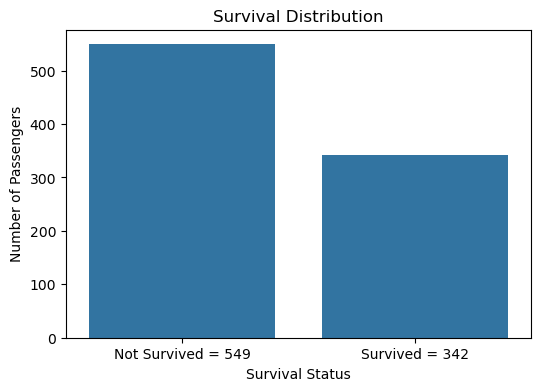

In [25]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_clean, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Survived = 549", "Survived = 342"])

plt.show()

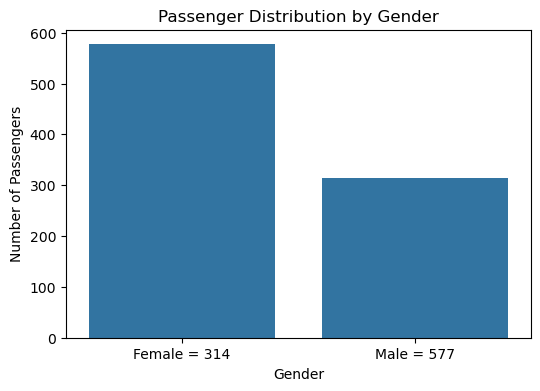

In [26]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_clean, x="Sex")

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Female = 314", "Male = 577"])

plt.show()

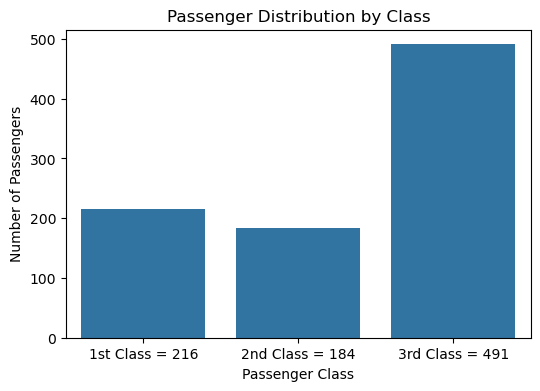

In [27]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_clean, x="Pclass")

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["1st Class = 216", "2nd Class = 184", "3rd Class = 491"])

plt.show()

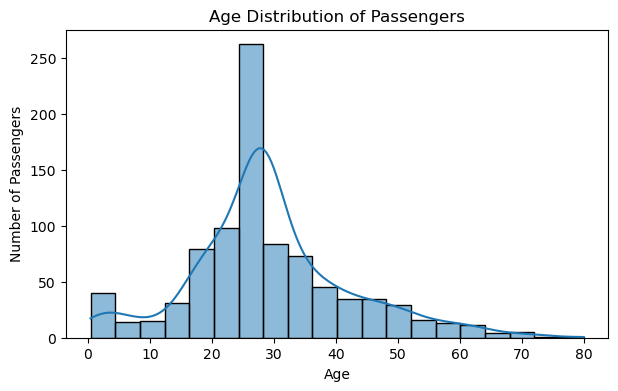

In [28]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df_clean, x="Age", bins=20, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

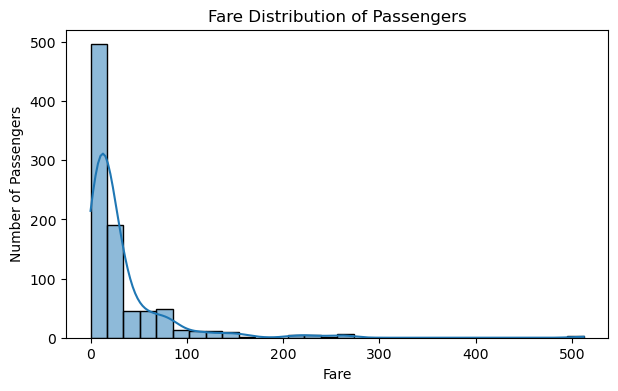

In [29]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df_clean, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution of Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

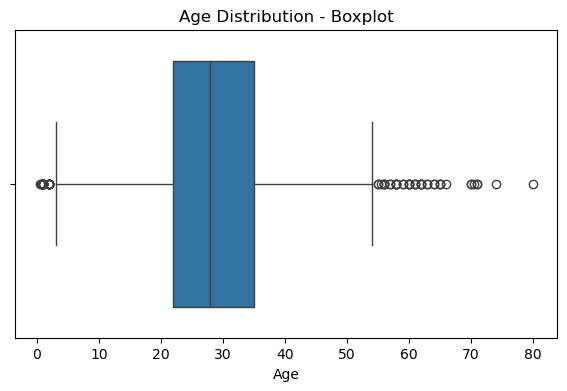

In [30]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Age")

plt.title("Age Distribution - Boxplot")
plt.xlabel("Age")

plt.show()

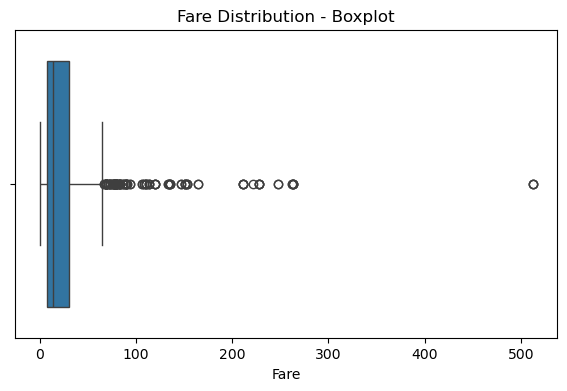

In [31]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Fare")

plt.title("Fare Distribution - Boxplot")
plt.xlabel("Fare")

plt.show()

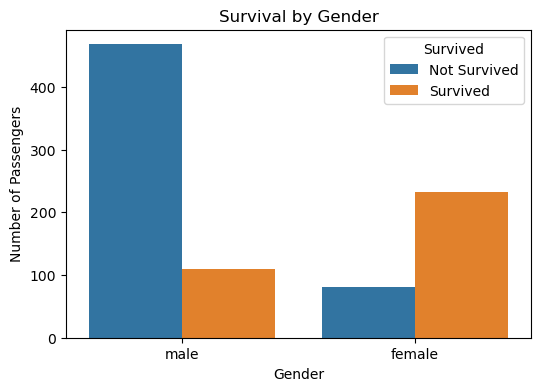

In [32]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_clean, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Not Survived", "Survived"])

plt.show()

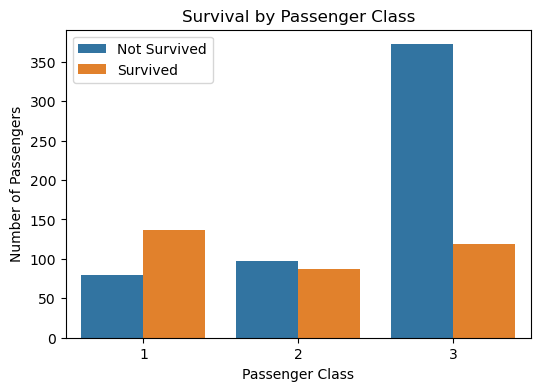

In [34]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_clean, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="", labels=["Not Survived", "Survived"])

plt.show()

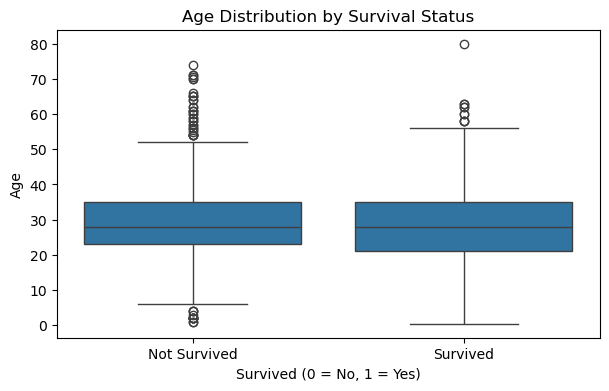

In [40]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Survived", y="Age")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.xticks([0, 1], ["Not Survived", "Survived"])

plt.show()

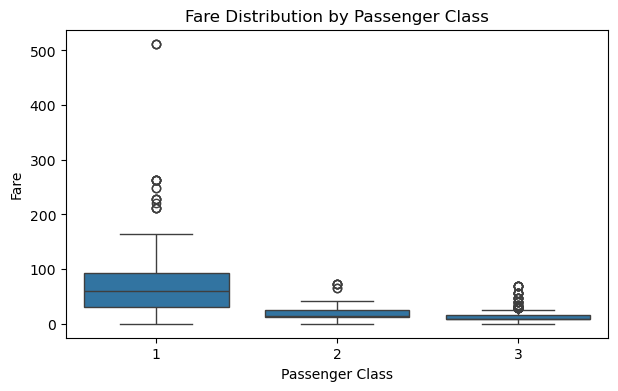

In [41]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Pclass", y="Fare")

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

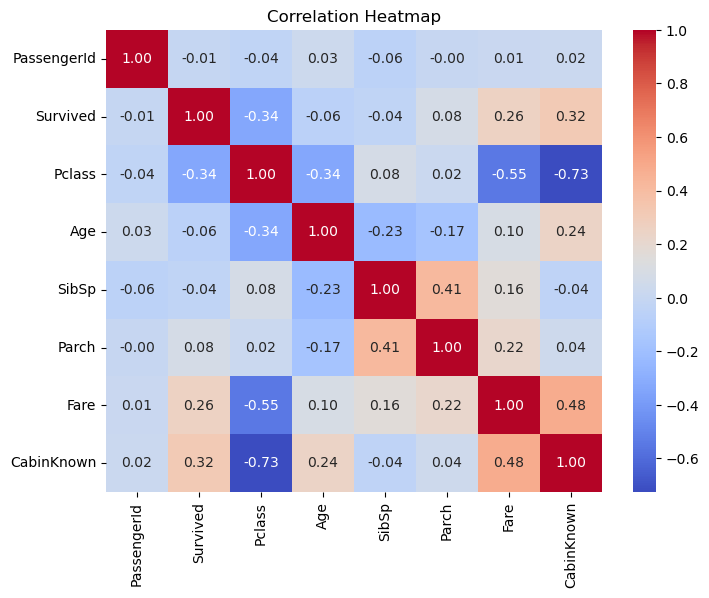

In [42]:
plt.figure(figsize=(8, 6))

corr = df_clean.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

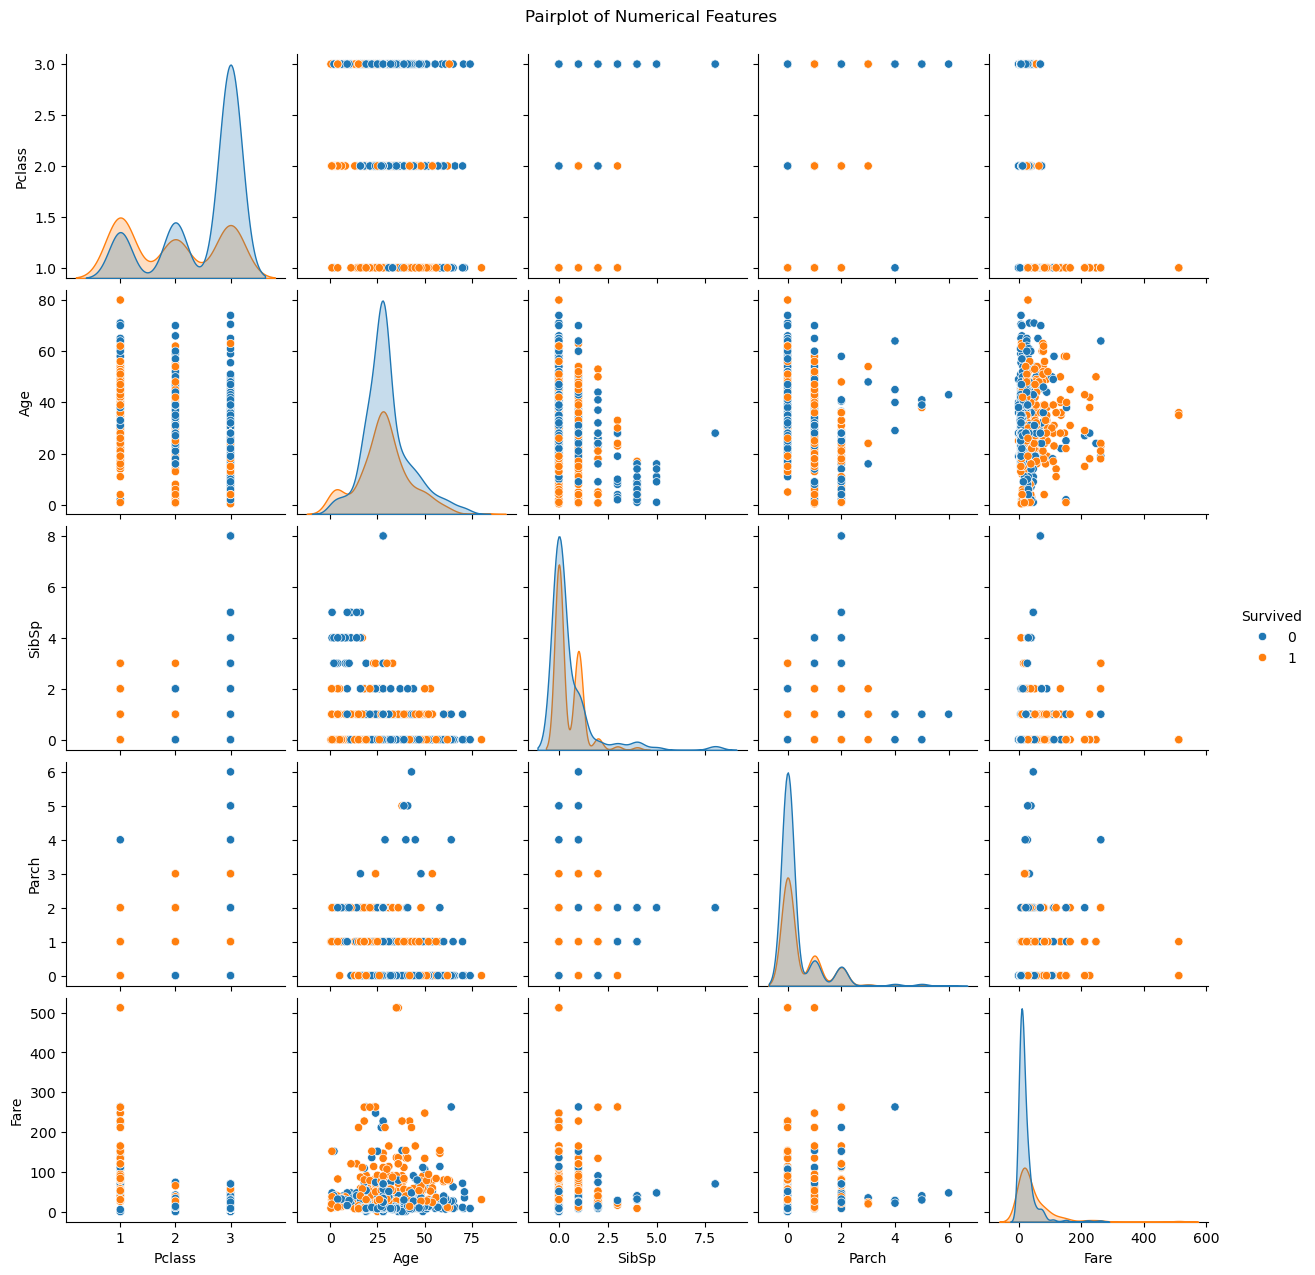

In [43]:
sns.pairplot(
    df_clean[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]],
    hue="Survived"
)

plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

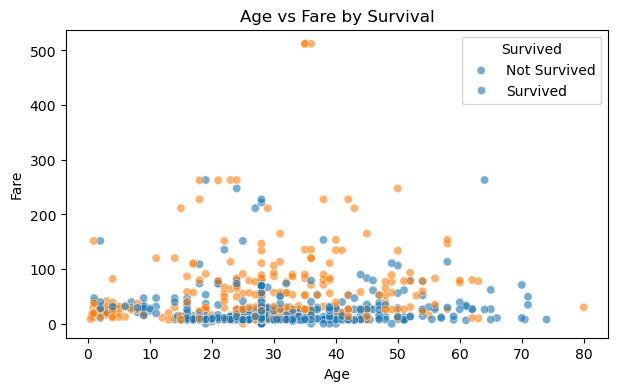

In [45]:
plt.figure(figsize=(7, 4))

sns.scatterplot(
    data=df_clean,
    x="Age",
    y="Fare",
    hue="Survived",
    alpha=0.6
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["Not Survived", "Survived"])

plt.show()

## Final Summary of Findings

- The Titanic dataset contains **891 passengers and 12 original features**.
- Overall, **342 passengers survived**, while **549 passengers did not survive**.
- **Age** was concentrated mainly between approximately 20 and 40 years.
- **Fare** was highly right-skewed, with most passengers paying lower fares and a small number paying very high fares.
- **Female passengers had a higher survival rate than male passengers.**
- **First-class passengers had better survival outcomes**, while third-class passengers had the highest number of non-survivors.
- The correlation heatmap showed a **negative relationship between Pclass and Survived**, indicating better survival among passengers in higher-status classes.
- The scatterplots showed that **Age alone did not have a strong relationship with survival**, while higher fares were more commonly associated with surviving passengers.
- The pairplot helped identify relationships and patterns among the numerical variables.

### Overall Conclusion

The EDA indicates that **gender, passenger class, and fare were important factors associated with survival**, while age alone showed a weaker relationship. The analysis demonstrates how exploratory data analysis can be used to identify important patterns and relationships before applying statistical or predictive models.